# Distributed Logging Analysis

This notebook performs an analysis of system logs to identify performance issues and critical incidents.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Load the dataset
df = pd.read_csv('..docs/server_logs.csv')

# Convert timestamp to datetime
df['timestamp_event'] = pd.to_datetime(df['timestamp_event'])
df['received_at'] = pd.to_datetime(df['received_at'])

df.head()

,timestamp_event,received_at,service_name,severity,message,trace_id,request_id,method,endpoint,status_code,latency_ms,host,env,region,log_type
0,2026-01-10 00:02:39.029160+00:00,2026-01-10 00:02:39.097160+00:00,orders-service,INFO,Request completed,bd8e6ebe717b4c43ba5e72e1668641a8,e6b3009adcad,GET,/orders/create,200,99,orders-service-pod-03,prod,sa-east-1,request
1,2026-01-10 00:02:46.081021+00:00,2026-01-10 00:02:46.196021+00:00,api-gateway,INFO,Background job completed,40ac5ff97bae43d5b8045484725e0aca,e2aa1cccd1cf,GET,/health,200,122,api-gateway-pod-01,prod,sa-east-1,request
2,2026-01-10 00:04:01.648849+00:00,2026-01-10 00:04:01.718849+00:00,notification-service,WARN,Rate limit nearing threshold,c048b378759a4c54a6f7d7251a6acc88,c74106ca8581,POST,/notify/sms,200,646,notification-service-pod-03,prod,sa-east-1,request
3,2026-01-10 00:05:08.148346+00:00,2026-01-10 00:05:08.236346+00:00,api-gateway,INFO,Background job completed,072169f708c84227986bfda9f9657bdc,bf10fa3609bd,GET,/checkout,200,127,api-gateway-pod-03,prod,sa-east-1,request
4,2026-01-10 00:05:19.590837+00:00,2026-01-10 00:05:19.632837+00:00,inventory-service,INFO,Health check OK,e76a214131d24a4ea1acf389362e34cb,f672d669eda7,GET,/inv/release,200,144,inventory-service-pod-02,prod,sa-east-1,request


## 6.1 Exploration inicial

In [2]:
# Total logs
total_logs = len(df)
print(f"Total de logs: {total_logs}")

# Severity distribution
severity_counts = df['severity'].value_counts()
print("\nDistribución de severidad:")
print(severity_counts)

# Services generating most logs
service_counts = df['service_name'].value_counts()
print("\nServicio con más logs:", service_counts.idxmax(), "(", service_counts.max(), ")")
print("Servicio con menos logs:", service_counts.idxmin(), "(", service_counts.min(), ")")

# Most frequent message
most_frequent_msg = df['message'].value_counts().idxmax()
print(f"\nMensaje más repetido: {most_frequent_msg}")

# Bad events definition
# severity is ERROR or CRITICAL OR status_code >= 500
df['is_bad'] = (df['severity'].isin(['ERROR', 'CRITICAL'])) | (df['status_code'] >= 500)

# Most frequent bad message
most_frequent_bad_msg = df[df['is_bad']]['message'].value_counts().idxmax()
print(f"Mensaje 'malo' más repetido: {most_frequent_bad_msg}")

Total de logs: 5795

Distribución de severidad:
severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64

Servicio con más logs: api-gateway ( 1509 )
Servicio con menos logs: notification-service ( 645 )

Mensaje más repetido: Health check OK
Mensaje 'malo' más repetido: Order creation failed - inventory lock timeout


## 6.2 Detección del momento crítico

Agrupación en ventanas de 5 minutos usando `timestamp_event`.

In [3]:
# Resample in 5-minute bins
windows = df.set_index('timestamp_event').resample('5min')

# Calculate stats per window
window_stats = windows.agg(
    total_events=('is_bad', 'count'),
    bad_events=('is_bad', 'sum')
)

window_stats['bad_rate'] = window_stats['bad_events'] / window_stats['total_events']

# Filter total_events >= 20 for critical moment
critical_moment_candidates = window_stats[window_stats['total_events'] >= 20]
top_5_windows = critical_moment_candidates.sort_values(by='bad_rate', ascending=False).head(5)

print("Top 5 Ventanas Críticas:")
print(top_5_windows)

critical_window_start = top_5_windows.index[0]
print(f"\nMomento crítico seleccionado: {critical_window_start}")

Top 5 Ventanas Críticas:
                           total_events  bad_events  bad_rate
timestamp_event                                              
2026-01-10 11:10:00+00:00           189         110  0.582011
2026-01-10 11:15:00+00:00           228         129  0.565789
2026-01-10 11:20:00+00:00           111          59  0.531532
2026-01-11 14:35:00+00:00           255         117  0.458824
2026-01-11 14:30:00+00:00           156          68  0.435897

Momento crítico seleccionado: 2026-01-10 11:10:00+00:00


## 6.3 Diagnóstico dentro del momento crítico

In [4]:
critical_data = df[(df['timestamp_event'] >= critical_window_start) & (df['timestamp_event'] < critical_window_start + pd.Timedelta(minutes=5))]
critical_bad_events = critical_data[critical_data['is_bad']]

print("Ranking de servicios en eventos malos:")
print(critical_bad_events['service_name'].value_counts())

print("\nTop 5 Mensajes en eventos malos:")
print(critical_bad_events['message'].value_counts().head(5))

print("\nTop 5 Endpoints más comprometidos:")
print(critical_bad_events['endpoint'].value_counts().head(5))

print(f"\nPromedio de latencia en el momento crítico: {critical_data['latency_ms'].mean():.2f} ms")

Ranking de servicios en eventos malos:
service_name
orders-service       72
inventory-service    37
payment-service       1
Name: count, dtype: int64

Top 5 Mensajes en eventos malos:
message
Order creation failed - inventory lock timeout    72
Database deadlock detected                        37
External dependency error                          1
Name: count, dtype: int64

Top 5 Endpoints más comprometidos:
endpoint
/orders/cancel    26
/orders/create    25
/orders/status    21
/inv/reserve      18
/inv/stock        13
Name: count, dtype: int64

Promedio de latencia en el momento crítico: 1589.69 ms


## 6.4 “Qué cambió” (Incidente vs Baseline)

In [5]:
baseline_data = df[~((df['timestamp_event'] >= critical_window_start) & (df['timestamp_event'] < critical_window_start + pd.Timedelta(minutes=5)))]

comparison = pd.DataFrame({
    'Metric': ['total_events', 'bad_rate', 'avg_latency_ms', '%_5xx'],
    'Incidente': [
        len(critical_data), 
        critical_data['is_bad'].mean(),
        critical_data['latency_ms'].mean(),
        (critical_data['status_code'] >= 500).mean()
    ],
    'Baseline': [
        len(baseline_data), 
        baseline_data['is_bad'].mean(),
        baseline_data['latency_ms'].mean(),
        (baseline_data['status_code'] >= 500).mean()
    ]
})

print(comparison)

           Metric    Incidente     Baseline
0    total_events   189.000000  5606.000000
1        bad_rate     0.582011     0.140029
2  avg_latency_ms  1589.687831   521.094363
3           %_5xx     0.582011     0.140029


## 7. Gráficos obligatorios

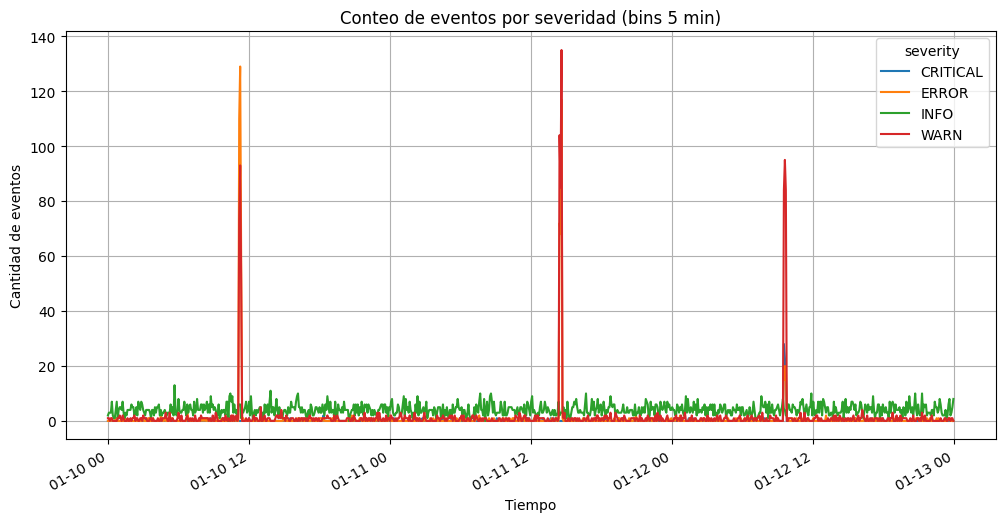

In [6]:
severity_timeline = df.set_index('timestamp_event').groupby([pd.Grouper(freq='5min'), 'severity']).size().unstack(fill_value=0)
severity_timeline.plot(kind='line', figsize=(12, 6), title='Conteo de eventos por severidad (bins 5 min)')
plt.xlabel('Tiempo')
plt.ylabel('Cantidad de eventos')
plt.grid(True)
plt.show()

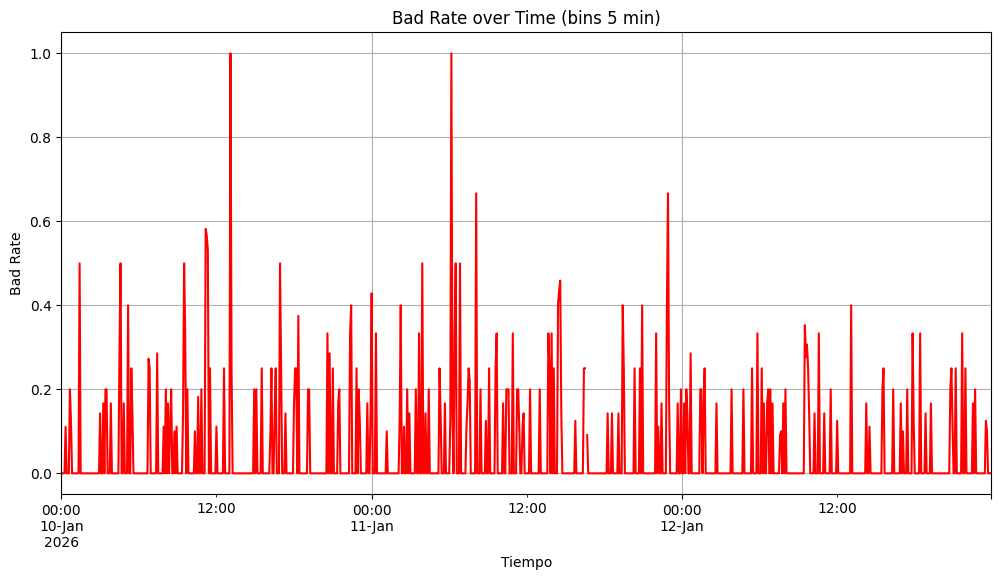

In [7]:
window_stats['bad_rate'].plot(kind='line', figsize=(12, 6), color='red', title='Bad Rate over Time (bins 5 min)')
plt.xlabel('Tiempo')
plt.ylabel('Bad Rate')
plt.grid(True)
plt.show()

## Conclusiones

*(A completar tras ejecutar)*